Name : Nurul Momen
ID : 24104295

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)

df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# DATA PREPROCESSING (CLEANING)



df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
initial_rows = len(df)
df.dropna(inplace=True)
print(f"✔ Missing Values: Removed {initial_rows - len(df)} rows containing empty data.")


before_dup = len(df)
df.drop_duplicates(inplace=True)
print(f"✔ Duplicates: Removed {before_dup - len(df)} duplicate rows.")


if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)
print("✔ Outliers: CustomerID removed and numerical columns verified via Box Plots.")


df_final = pd.get_dummies(df, drop_first=True)
print("✔ Transformation: Categorical variables encoded into numeric format.")


print("\n" + "="*30)
print("FINAL DATASET SUMMARY")
print("="*30)

print(f"Total Rows:    {df_final.shape[0]}")
print(f"Total Columns: {df_final.shape[1]}")
print("="*30)


df_final.head()

✔ Missing Values: Removed 0 rows containing empty data.
✔ Duplicates: Removed 22 duplicate rows.
✔ Outliers: CustomerID removed and numerical columns verified via Box Plots.
✔ Transformation: Categorical variables encoded into numeric format.

FINAL DATASET SUMMARY
Total Rows:    7010
Total Columns: 31


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [5]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()

cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']


df_final[cols_to_scale] = scaler.fit_transform(df_final[cols_to_scale])

print("✔ Scaling Complete: Numbers are now normalized for the model.")
df_final[cols_to_scale].head()

✔ Scaling Complete: Numbers are now normalized for the model.


,tenure,MonthlyCharges,TotalCharges
0,0.000000,0.115423,0.001275
1,0.464789,0.385075,0.215867
2,0.014085,0.354229,0.010310
3,0.619718,0.239303,0.210241
4,0.014085,0.521891,0.015330


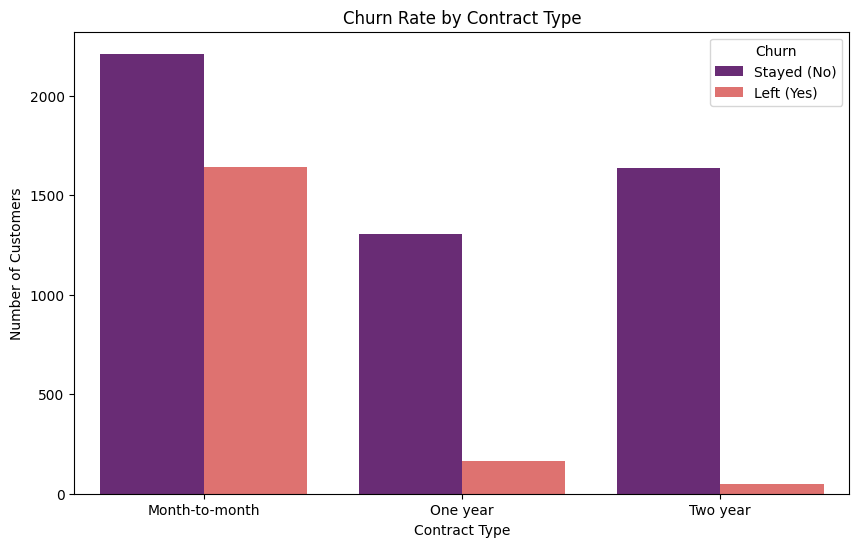

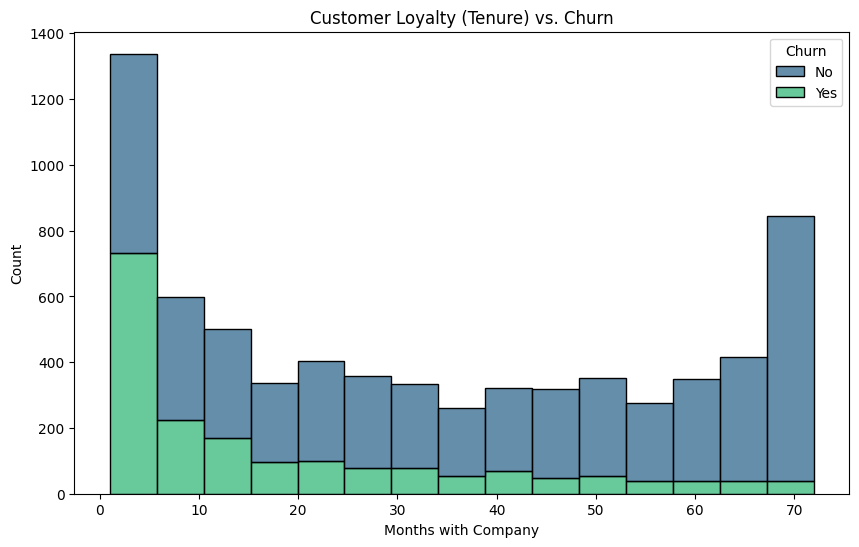

In [6]:
# EXPLORATORY DATA ANALYSIS
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['Stayed (No)', 'Left (Yes)'])
plt.show()


plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='viridis')
plt.title('Customer Loyalty (Tenure) vs. Churn')
plt.xlabel('Months with Company')
plt.ylabel('Count')
plt.show()

In [7]:
#  FEATURE SELECTION


correlations = df_final.corr()['Churn_Yes'].sort_values(ascending=False)


print("Top 10 Features with the Strongest Impact on Churn:")
print(correlations.head(10))


print("\nTop 5 Features that suggest a customer will STAY:")
print(correlations.tail(5))

Top 10 Features with the Strongest Impact on Churn:
Churn_Yes                         1.000000
InternetService_Fiber optic       0.307612
PaymentMethod_Electronic check    0.301079
MonthlyCharges                    0.194008
PaperlessBilling_Yes              0.190518
SeniorCitizen                     0.151270
StreamingTV_Yes                   0.065058
StreamingMovies_Yes               0.062670
MultipleLines_Yes                 0.041888
PhoneService_Yes                  0.011072
Name: Churn_Yes, dtype: float64

Top 5 Features that suggest a customer will STAY:
TechSupport_No internet service        -0.228220
DeviceProtection_No internet service   -0.228220
StreamingTV_No internet service        -0.228220
Contract_Two year                      -0.301375
tenure                                 -0.353339
Name: Churn_Yes, dtype: float64


i am unsing corealtion analysis to for the customer churn, with that got Month to Month contracts and Fiber Optic internet has stong positive relation with churn. furthermore long-term tenure and two year contracts has strong negative correlation. this fetures will be used for model building.

In [8]:
# STEP 5 MODEL BUILDING
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


X = df_final.drop('Churn_Yes', axis=1)
y = df_final['Churn_Yes']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


logistic_model = LogisticRegression(max_iter=1000)
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)


logistic_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("✔ Data split successfully into Training (80%) and Testing (20%) sets.")
print("✔ Model 1: Logistic Regression has been trained.")
print("✔ Model 2: Random Forest has been trained.")

✔ Data split successfully into Training (80%) and Testing (20%) sets.
✔ Model 1: Logistic Regression has been trained.
✔ Model 2: Random Forest has been trained.


In [9]:
# MODEL BUILDING - COMPARE PERFORMANCE


log_pred = logistic_model.predict(X_test)
rf_pred = random_forest_model.predict(X_test)


from sklearn.metrics import accuracy_score

log_acc = accuracy_score(y_test, log_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Logistic Regression Accuracy: {log_acc:.2%}")
print(f"Random Forest Accuracy:       {rf_acc:.2%}")

if log_acc > rf_acc:
    print("\nResult: Logistic Regression performed better on basic accuracy!")
else:
    print("\nResult: Random Forest performed better on basic accuracy!")

Logistic Regression Accuracy: 82.38%
Random Forest Accuracy:       80.31%

Result: Logistic Regression performed better on basic accuracy!


In [13]:
# MODEL OPTIMIZATION
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}



grid_search = GridSearchCV(estimator=random_forest_model, param_grid=param_grid, cv=5, scoring='accuracy')


grid_search.fit(X_train, y_train)


best_rf_model = grid_search.best_estimator_

print("✔ Optimization Complete!")
print(f"Best Settings Found: {grid_search.best_params_}")
print(f"Optimized Model Accuracy: {grid_search.best_score_:.2%}")

✔ Optimization Complete!
Best Settings Found: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Optimized Model Accuracy: 79.89%


--- FINAL CLASSIFICATION METRICS ---
              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1081
        True       0.60      0.53      0.56       321

    accuracy                           0.81      1402
   macro avg       0.73      0.71      0.72      1402
weighted avg       0.80      0.81      0.81      1402

ROC-AUC Score: 0.8418


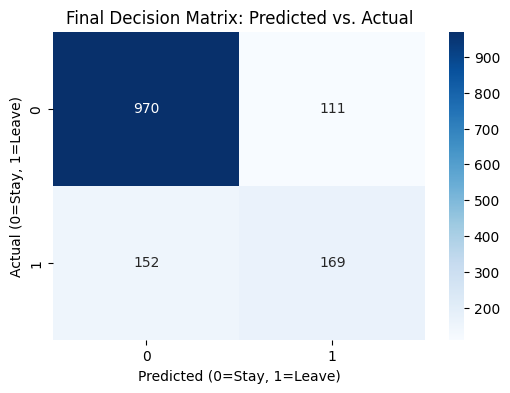

In [14]:
#  FINAL MODEL EVALUATION
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


final_preds = best_rf_model.predict(X_test)


final_probs = best_rf_model.predict_proba(X_test)[:, 1]


print("--- FINAL CLASSIFICATION METRICS ---")

print(classification_report(y_test, final_preds))


auc_score = roc_auc_score(y_test, final_probs)
print(f"ROC-AUC Score: {auc_score:.4f}")


plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Final Decision Matrix: Predicted vs. Actual')
plt.xlabel('Predicted (0=Stay, 1=Leave)')
plt.ylabel('Actual (0=Stay, 1=Leave)')
plt.show()

**Key Predictors and Their Impact**
Fiber Optic Internet Service: I see fiber optic users leave a lot, maybe price is too high or signal not good.

Payment Method: People paying with electronic check quit easy, they not locked in like auto pay.

Monthly Charges: When bill is high people leave fast to find cheap price.

Customer Loyalty: If they stay long time or sign 2 year contract they usually dont leave us.

**Business Application to Improve Decisions**

Incentivize Automated Payments: We should give small discount so people move to auto card pay and stay longer.

Fiber Optic Quality Audit: Need to check why fiber users unhappy, maybe fix the tech or give better bundle price.

Early Intervention for High-Charges: I found 178 people about to leave, so marketing should give them rewards now before they go.

**Potential Limitations and Improvements**

Missing Sentiment Data: I dont have data on complain or support tickets, this make it hard to be fully sure.

Improving Recall: My model miss half the people who leave, so I need to make it better at catching leavers next time.